# Project 1

## Import the required packages and set file path

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os 
os.chdir("/Users/feng/Desktop/Investment/group")

## Read and clean the data

In [2]:
# read the data
df = pd.read_csv("SP500_Full_OHLCV_Final.csv",parse_dates=["Date"],dtype={"Ticker": str,"Close": float,"High": float,"Low": float,"Open": float,"Volume": float}) 
spy_df = pd.read_excel("SP500.xlsx", index_col='Date', parse_dates=['Date'])

In [3]:
# check the stock price data
ticker_count = df['Ticker'].nunique()
date_count = df['Date'].nunique()
total_rows = len(df)
print(f"Number of stocks: {ticker_count}")
print(f"Number of trading days): {date_count}")
print(f"Number of rows: {total_rows}")

Number of stocks: 503
Number of trading days): 2060
Number of rows: 1036180


In [4]:
# check missing rows
missing_values = df.iloc[:, 2:7].isna().sum()
zero_values = (df.iloc[:, 2:7] == 0).sum()
summary = pd.DataFrame({' Missing': missing_values,'Zero': zero_values})
print(summary)

         Missing  Zero
Close      21158     0
High       21158     0
Low        21158     0
Open       21158     0
Volume     21158  1049


In [5]:
# drop missing rows
df['Suspended'] = np.where(df['Volume'] == 0, 1, 0)
initial_count = len(df)
df_cleaned = df.dropna(axis=0, how='any').copy()
final_count = len(df_cleaned)
dropped_count = initial_count - final_count
suspended_count = df_cleaned['Suspended'].sum()
df = df_cleaned
print(f"Number of dropped rows: {dropped_count}")
print(f"Number of final rows: {final_count}")
print(f"Number of suspended rows: {suspended_count}")

Number of dropped rows: 21158
Number of final rows: 1015022
Number of suspended rows: 1049


In [6]:
# calculate return
## benchmark return
spy_df.sort_index(ascending=True, inplace=True)
spy_df['ben_daily_return'] = spy_df['Benchmark'].pct_change()
df = df.sort_values(['Ticker', 'Date'])
df['Return'] = df.groupby('Ticker')['Close'].pct_change()

## stock retuen
df = df.sort_values(['Ticker', 'Date'])
df['Retu## Read and clean the datarn'] = df.groupby('Ticker')['Close'].pct_change()

In [7]:
# check the processed data
print(df.head(3))
print(spy_df.head(3))

           Date Ticker      Close       High        Low       Open     Volume  \
0    2018-01-03      A  65.287666  65.447776  63.667717  63.686558  1698900.0   
503  2018-01-04      A  64.797905  65.758568  64.779064  65.494857  2230700.0   
1006 2018-01-05      A  65.833923  66.022286  64.731984  64.731984  1632500.0   

      Suspended    Return  Retu## Read and clean the datarn  
0             0       NaN                               NaN  
503           0 -0.007502                         -0.007502  
1006          0  0.015988                          0.015988  
            Benchmark  ben_daily_return
Date                                   
2018-01-03    2713.06               NaN
2018-01-04    2723.99          0.004029
2018-01-05    2743.15          0.007034


## Describe the data

In [8]:
# calculate derived data
## stock return and vol
stock_metrics = df.groupby('Ticker')['Return'].agg([
    ('Annual_Return', lambda x: x.mean() * 252),
    ('Annual_Volatility', lambda x: x.std() * np.sqrt(252))
]).reset_index()

## market volume
daily_market_volume = df.groupby('Date')['Volume'].sum().reset_index()
daily_market_volume.rename(columns={'Volume': 'Total_Market_Volume'}, inplace=True)

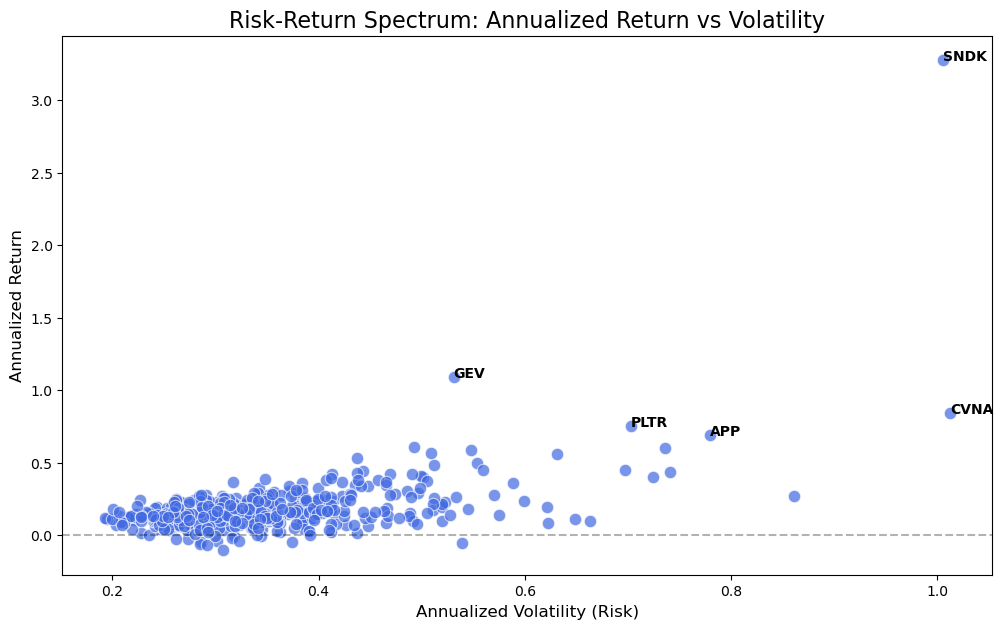

In [9]:
# Figure 1: Risk-Return Spectrum
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    data=stock_metrics, 
    x='Annual_Volatility', 
    y='Annual_Return', 
    alpha=0.7, 
    s=80, 
    color='royalblue'
)

top_stocks = stock_metrics.nlargest(5, 'Annual_Return')
for _, row in top_stocks.iterrows():
    plt.text(
        row['Annual_Volatility'], 
        row['Annual_Return'], 
        row['Ticker'], 
        fontsize=10, 
        fontweight='bold'
    )
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Risk-Return Spectrum: Annualized Return vs Volatility', fontsize=16)
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.show()

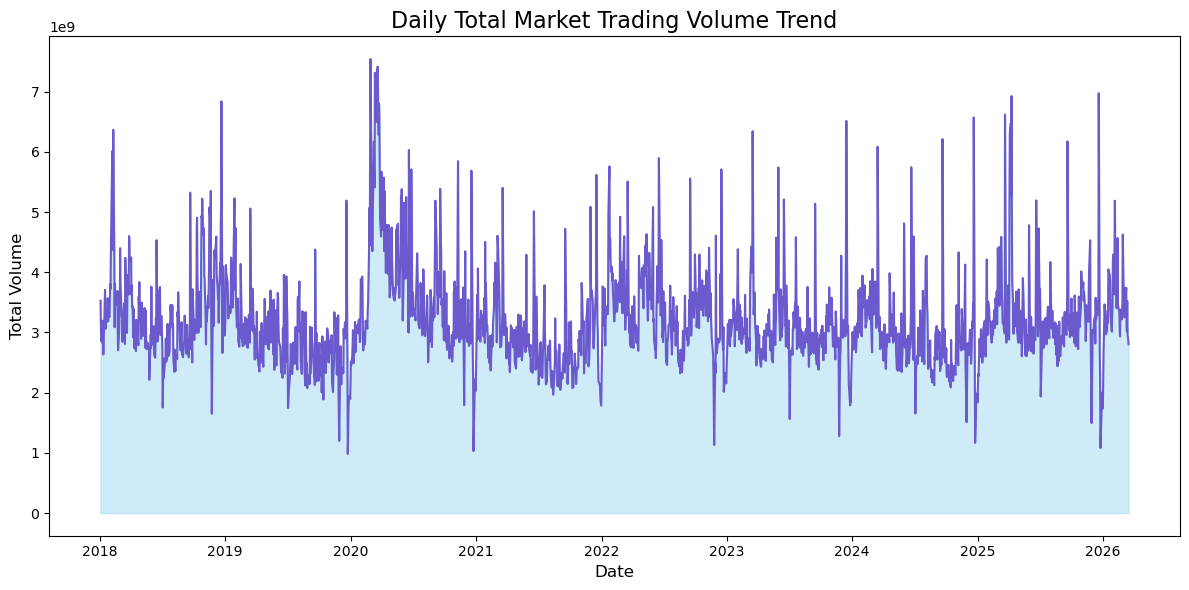

In [10]:
# Figure 2: Market Volume Trend
plt.figure(figsize=(12, 6))
plt.fill_between(
    daily_market_volume['Date'], 
    daily_market_volume['Total_Market_Volume'], 
    color="skyblue", 
    alpha=0.4
)
plt.plot(
    daily_market_volume['Date'], 
    daily_market_volume['Total_Market_Volume'], 
    color="Slateblue", 
    lw=1.5
)
plt.title('Daily Total Market Trading Volume Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Volume', fontsize=12)
plt.tight_layout()
plt.show()

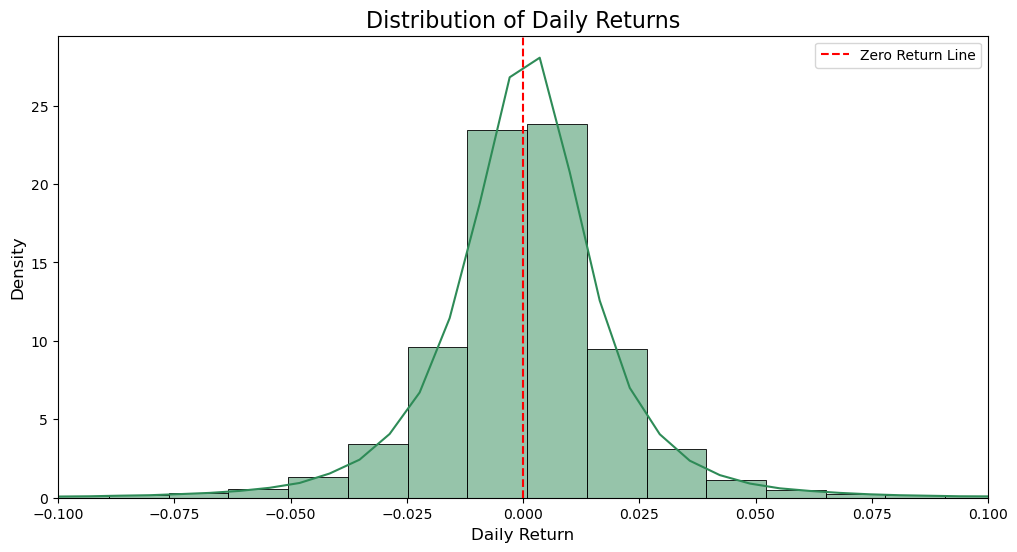

In [11]:
# Figure 3: Daily Returns Distribution
plt.figure(figsize=(12, 6))
returns_data = df['Return'].dropna()
sns.histplot(returns_data, bins=100, kde=True, color='seagreen', stat="density")
plt.xlim(-0.1, 0.1) 
plt.axvline(0, color='red', linestyle='--', label='Zero Return Line')
plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

## Design the strategy

In [12]:
# standardization functio
def standardize(f_df):
    return f_df.sub(f_df.mean(axis=1), axis=0).div(f_df.std(axis=1), axis=0)

In [13]:
# performance print function
def calculate_backtest_performance(df, start_date, end_date, turnover_list=None, ic_list=None):
    
    df.index = pd.to_datetime(df.index)
    temp_df = df.loc[start_date:end_date].copy()
    
    if temp_df.empty:
        return pd.DataFrame(columns=["Strategy", "Benchmark"])
    
    temp_df['strategy_net'] = (1 + temp_df['daily_return']).cumprod()
    temp_df['benchmark_net'] = (1 + temp_df['ben_daily_return']).cumprod()
    
    res = temp_df['daily_return']
    cum_ret = temp_df['strategy_net']
    ben_res = temp_df['ben_daily_return']
    ben_cum_ret = temp_df['benchmark_net']
    
    days_count = len(temp_df)
    ann_factor = 252 

    def get_metrics(returns, nav, is_ben=False):
        total_ret = nav.iloc[-1] - 1
        ann_ret = (nav.iloc[-1] ** (ann_factor / days_count)) - 1
        ann_vol = returns.std() * np.sqrt(ann_factor)
        sharpe = (returns.mean() * ann_factor) / ann_vol if ann_vol != 0 else np.nan
        max_dd = (nav / nav.cummax() - 1).min()
        
        if is_ben:
            return total_ret, ann_ret, ann_vol, sharpe, max_dd, np.nan, np.nan
        
        calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
        downside_res = returns[returns < 0]
        downside_std = downside_res.std() * np.sqrt(ann_factor)
        sortino = (returns.mean() * ann_factor) / downside_std if (len(downside_res) > 0 and downside_std != 0) else np.nan
        return total_ret, ann_ret, ann_vol, sharpe, max_dd, calmar, sortino

    s_metrics = get_metrics(res, cum_ret)
    b_metrics = get_metrics(ben_res, ben_cum_ret, is_ben=True)

    excess_ret_series = res - ben_res
    excess_cum_curve = (1 + excess_ret_series).cumprod()
    
    excess_total_ret = s_metrics[0] - b_metrics[0]
    excess_ann_ret = s_metrics[1] - b_metrics[1]
    max_excess_dd = (excess_cum_curve / excess_cum_curve.cummax() - 1).min()
    excess_vol = excess_ret_series.std() * np.sqrt(ann_factor)
    ir = (excess_ret_series.mean() * ann_factor) / excess_vol if excess_vol != 0 else np.nan

    perf_dict = {
    "Cumulative Return": [s_metrics[0], b_metrics[0]],
    "Annualized Return": [s_metrics[1], b_metrics[1]],
    "Annualized Volatility": [s_metrics[2], b_metrics[2]],
    "Maximum Drawdown": [s_metrics[4], b_metrics[4]],
    "Sharpe Ratio": [s_metrics[3], b_metrics[3]],
    "Sortino Ratio": [s_metrics[6], np.nan],
    "Calmar Ratio": [s_metrics[5], np.nan],
    "Excess Cumulative Return": [excess_total_ret, np.nan],
    "Excess Annualized Return": [excess_ann_ret, np.nan],
    "Excess Maximum Drawdown": [max_excess_dd, np.nan],
    "Information Ratio (IR)": [ir, np.nan],
    "Average Turnover Rate": [np.mean(turnover_list) if turnover_list is not None else np.nan, np.nan],
    "Average IC Value": [np.nanmean(ic_list) if ic_list is not None else np.nan, np.nan]
}
    results_df = pd.DataFrame(perf_dict, index=["Strategy Performance", "Banchmark Performance"]).T
    return results_df

In [14]:
# strategy

## data form transformation
prices = df.pivot(index='Date', columns='Ticker', values='Close')
daily_rets = prices.pct_change(fill_method=None)
opens = df.pivot(index='Date', columns='Ticker', values='Open')
high = df.pivot(index='Date', columns='Ticker', values='High')
low = df.pivot(index='Date', columns='Ticker', values='Low')
volume = df.pivot(index='Date', columns='Ticker', values='Volume')


## factors and signal
#######################################################################################################

f_gap = (opens / prices.shift(1) - 1).rolling(252).sum() # Factor 1: Mom_Gap
f_rel = daily_rets.sub(daily_rets.mean(axis=1), axis=0).rolling(252).sum() # Factor 2: Rel_Strength
f_vol = volume.rolling(20).mean() / volume.rolling(252).mean() # Factor 3: Vol_Trend

# standardization
s_gap = standardize(f_gap).fillna(0)
s_rel = standardize(f_rel).fillna(0)
s_vol = standardize(f_vol).fillna(0)

# generate final signal
final_signal = (s_gap + s_rel + s_vol) / 3
# final_signal = s_vol


#######################################################################################################

mask = (final_signal != 0).any(axis=1)
first_valid_index = mask.idxmax()
final_signal = final_signal.loc[first_valid_index:]

# adjustment frequency
monthly_signal = final_signal.resample('ME').last()
daily_rets_all = prices.pct_change(fill_method=None)

strat_segments, turnover_list, ic_list = [], [], []
last_weights = pd.Series(0.0, index=prices.columns)

for i in range(len(monthly_signal.index) - 1):
    
    curr_date = monthly_signal.index[i]
    next_date = monthly_signal.index[i+1]
    s = monthly_signal.loc[curr_date].dropna()
    
    price_curr = prices.reindex([curr_date], method='ffill').iloc[0]
    price_next = prices.reindex([next_date], method='ffill').iloc[0]
    r = (price_next / price_curr - 1)
    
    common = s.index.intersection(prices.columns)
    
    if len(common) > 50:
        
        ic_list.append(s[common].corr(r[common]))
        
        # Stock selection rules
        top = s[common].nlargest(int(len(common) * 0.05)).index
        
        curr_w = pd.Series(0.0, index=prices.columns) # turnover 
        curr_w[top] = 1.0 / len(top)
        turnover = (curr_w - last_weights).abs().sum() / 2
        turnover_list.append(turnover)
        last_weights = curr_w
        
        month_daily_rets = daily_rets_all.loc[curr_date:next_date, top].iloc[1:]
        daily_portfolio_rets = month_daily_rets.mean(axis=1)
        strat_segments.append(daily_portfolio_rets)

res = pd.concat(strat_segments)
if len(res) > 0:
    res.iloc[0] = 0
cum_ret = (1 + res).cumprod()
perf_df = pd.DataFrame({'daily_return': res, 'cumulative_net_value': cum_ret})

start_time = res.index[0] 
end_time = res.index[-1]
trading_days_count = len(res)

spy_df = spy_df.loc[start_time:end_time]
spy_df.iloc[0, spy_df.columns.get_loc('ben_daily_return')] = 0
spy_df['ben_net_value'] = (1 + spy_df['ben_daily_return']).cumprod()

merged_df = perf_df.join(spy_df, how='left', lsuffix='_perf', rsuffix='_spy')
merged_df = merged_df.drop('Benchmark', axis=1)
merged_df['excess_return'] = merged_df['daily_return'] - merged_df['ben_daily_return']

print(calculate_backtest_performance(merged_df, "2019-01-01", "2026-12-31", turnover_list=turnover_list, ic_list=ic_list))

                          Strategy Performance  Banchmark Performance
Cumulative Return                     9.523535               1.295038
Annualized Return                     0.400196               0.126160
Annualized Volatility                 0.294673               0.197782
Maximum Drawdown                     -0.353086              -0.368331
Sharpe Ratio                          1.290974               0.700100
Sortino Ratio                         1.674985                    NaN
Calmar Ratio                          1.133423                    NaN
Excess Cumulative Return              8.228496                    NaN
Excess Annualized Return              0.274036                    NaN
Excess Maximum Drawdown              -0.173224                    NaN
Information Ratio (IR)                1.388076                    NaN
Average Turnover Rate                 0.421163                    NaN
Average IC Value                      0.038940                    NaN


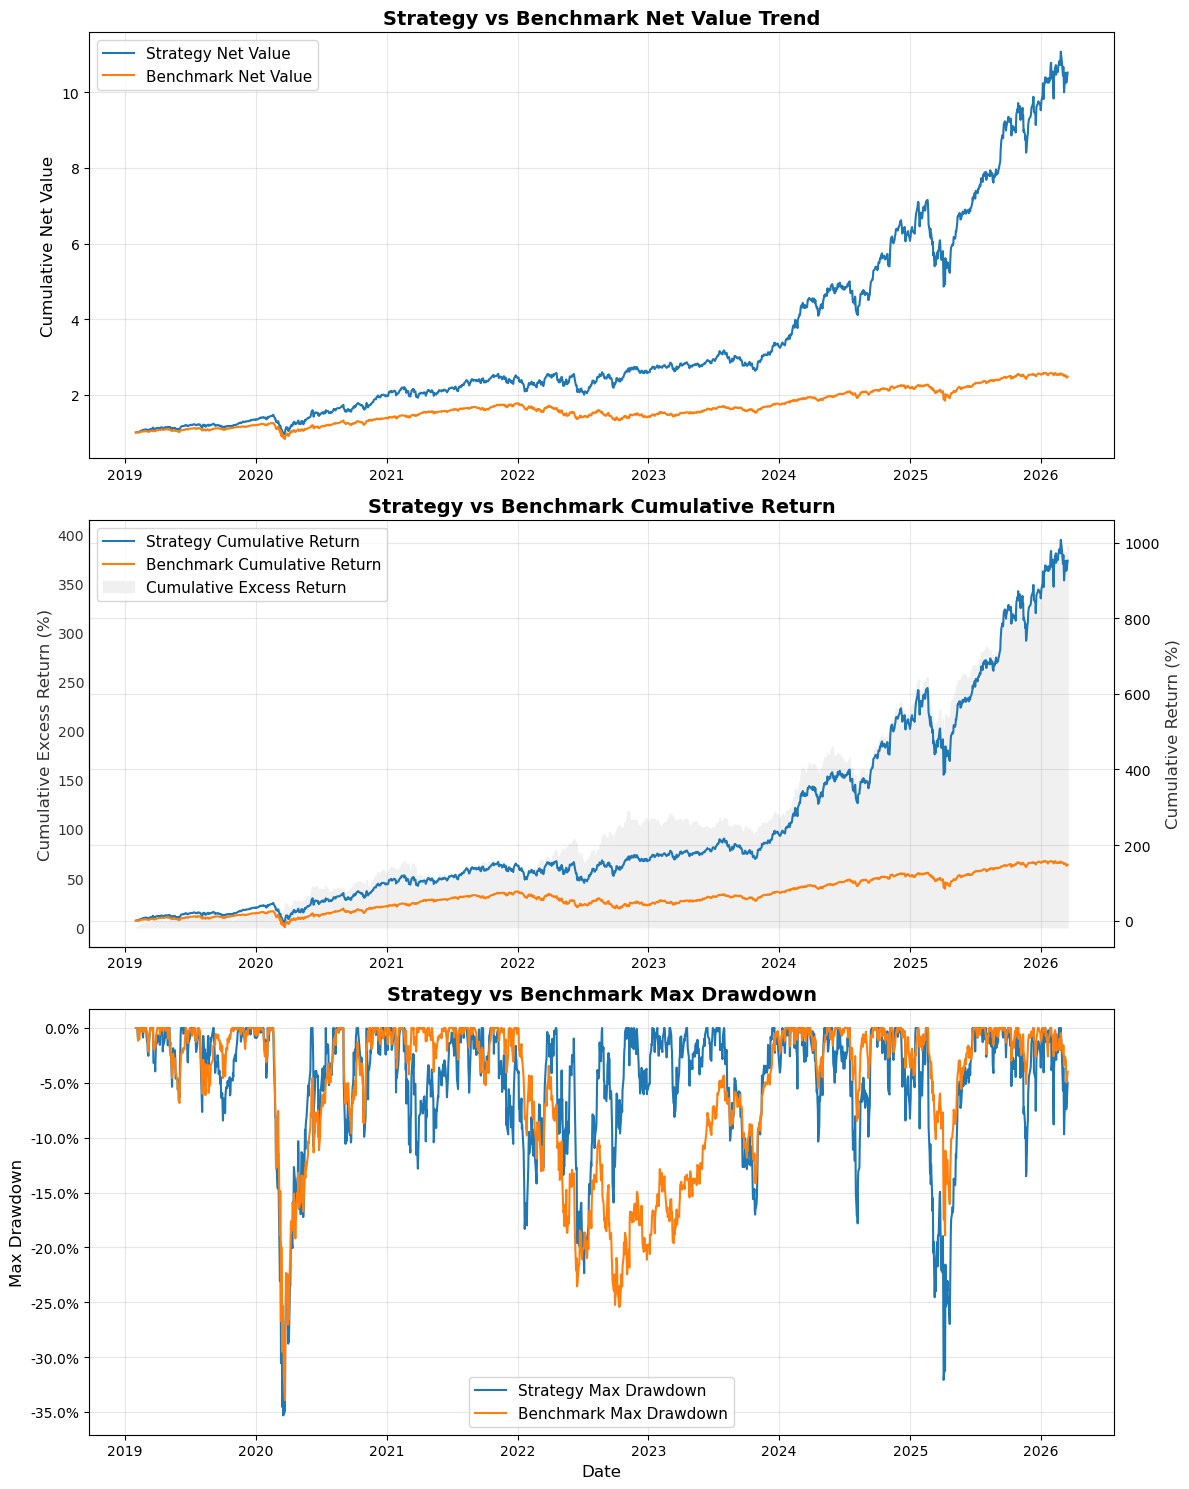

In [15]:
merged_df['cum_excess_return'] = ((1 + merged_df['excess_return']).cumprod() - 1) * 100 # Cumulative excess return 
def calculate_max_drawdown(net_value_series): # Max Drawdown Calculation Function
    running_max = net_value_series.cummax()
    drawdown = (net_value_series - running_max) / running_max
    return drawdown
merged_df['strategy_max_drawdown'] = calculate_max_drawdown(merged_df['cumulative_net_value']) # Calculate max drawdown for strategy and benchmark
merged_df['benchmark_max_drawdown'] = calculate_max_drawdown(merged_df['ben_net_value'])

# Performance
fig, axes = plt.subplots(3, 1, figsize=(12, 15))  # 3 rows, 1 column

## Plot 1: Strategy vs Benchmark Net Value
axes[0].plot(merged_df.index, merged_df['cumulative_net_value'], label='Strategy Net Value', color='#1f77b4', linewidth=1.5)
axes[0].plot(merged_df.index, merged_df['ben_net_value'], label='Benchmark Net Value', color='#ff7f0e', linewidth=1.5)
axes[0].set_title('Strategy vs Benchmark Net Value Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cumulative Net Value', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

## Plot 2: Cumulative Return + Cumulative Excess Return (Dual Axis)
merged_df['strategy_cum_ret'] = (merged_df['cumulative_net_value'] - 1) * 100
merged_df['benchmark_cum_ret'] = (merged_df['ben_net_value'] - 1) * 100
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.set_zorder(ax2_twin.get_zorder() + 1) 
ax2.patch.set_visible(False)              
ax2_twin.yaxis.set_label_position("left")
ax2_twin.yaxis.set_ticks_position("left")
ax2_twin.fill_between(merged_df.index, 0, merged_df['cum_excess_return'], 
                      color='#f0f0f0', alpha=1.0, 
                      label='Cumulative Excess Return')
ax2_twin.grid(False)
ax2_twin.spines['right'].set_visible(False)
ax2_twin.spines['top'].set_visible(False)
ax2_twin.set_ylabel('Cumulative Excess Return (%)', fontsize=12, color='#333333')
ax2_twin.tick_params(axis='y', labelcolor='#333333', length=0)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_ticks_position("right")
ax2.plot(merged_df.index, merged_df['strategy_cum_ret'], 
         label='Strategy Cumulative Return', color='#1f77b4', linewidth=1.5)
ax2.plot(merged_df.index, merged_df['benchmark_cum_ret'], 
         label='Benchmark Cumulative Return', color='#ff7f0e', linewidth=1.5)
ax2.set_title('Strategy vs Benchmark Cumulative Return', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cumulative Return (%)', fontsize=12, color='#333333')
ax2.tick_params(axis='y', labelcolor='black')
ax2.grid(True, alpha=0.3)
lines_main, labels_main = ax2.get_legend_handles_labels()
lines_twin, labels_twin = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_main + lines_twin, labels_main + labels_twin, 
           loc='upper left', fontsize=11, frameon=True).set_zorder(20)

# Plot 3: Max Drawdown
axes[2].plot(merged_df.index, merged_df['strategy_max_drawdown'], label='Strategy Max Drawdown', color='#1f77b4', linewidth=1.5)
axes[2].plot(merged_df.index, merged_df['benchmark_max_drawdown'], label='Benchmark Max Drawdown', color='#ff7f0e', linewidth=1.5)
axes[2].set_title('Strategy vs Benchmark Max Drawdown', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Max Drawdown', fontsize=12)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# print(calculate_backtest_performance(merged_df, "2019-01-01", "2026-12-31", turnover_list=turnover_list, ic_list=ic_list))
# print(calculate_backtest_performance(merged_df, "2019-01-01", "2019-12-31", turnover_list=turnover_list, ic_list=ic_list))
# print(calculate_backtest_performance(merged_df, "2020-01-01", "2020-12-31", turnover_list=turnover_list, ic_list=ic_list))
# print(calculate_backtest_performance(merged_df, "2021-01-01", "2021-12-31", turnover_list=turnover_list, ic_list=ic_list))
# print(calculate_backtest_performance(merged_df, "2022-01-01", "2022-12-31", turnover_list=turnover_list, ic_list=ic_list))
# print(calculate_backtest_performance(merged_df, "2023-01-01", "2023-12-31", turnover_list=turnover_list, ic_list=ic_list))
# print(calculate_backtest_performance(merged_df, "2024-01-01", "2024-12-31", turnover_list=turnover_list, ic_list=ic_list))
# print(calculate_backtest_performance(merged_df, "2025-01-01", "2025-12-31", turnover_list=turnover_list, ic_list=ic_list))